In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt/pytorch/best_joint_checkpoint/1/best_joint_checkpoint.pt


In [3]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, Wav2Vec2Processor, Wav2Vec2Model
import torchaudio
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("SECTION 1: ENVIRONMENT CHECK")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU detected: {gpu_name}")
    print(f"VRAM: {gpu_mem:.1f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. wav2vec2 extraction over thousands of segments "
          "will be very slow on CPU — strongly recommend enabling a Kaggle GPU.")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    HF_TOKEN = secrets.get_secret("HF_TOKEN3")
    print("HF_TOKEN loaded from Kaggle Secrets.")
except Exception as e:
    HF_TOKEN = os.environ.get("HF_TOKEN3")
    if HF_TOKEN:
        print("HF_TOKEN loaded from environment variable.")
    else:
        print(f"WARNING: Could not load HF_TOKEN: {e}")
        print("MentalBERT requires authentication. Add HF_TOKEN as a Kaggle Secret.")

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

SECTION 1: ENVIRONMENT CHECK
GPU detected: Tesla T4
VRAM: 14.6 GB
PyTorch version: 2.10.0+cu128
Device: cuda
HF_TOKEN loaded from Kaggle Secrets.
Checkpoint directory: /kaggle/working/checkpoints


In [4]:
print("SECTION 2: LOAD PHASE 4 JOINT MODEL")

JOINT_CKPT_DIR = "/kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt/pytorch/best_joint_checkpoint/1"
JOINT_CKPT_PATH = os.path.join(JOINT_CKPT_DIR, "best_joint_checkpoint.pt")

tokenizer = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased", token=HF_TOKEN)


class JointModel(nn.Module):
    '''Shared MentalBERT backbone with Head 1 (condition, 5-class) and Head 2 (cause, 6-class).
    Must match the Phase 4 training notebook's class definition exactly.'''

    def __init__(self, backbone, num_condition=5, num_cause=6, dropout_rate=0.1):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout_rate)
        self.head1_classifier = nn.Linear(768, num_condition)
        self.head2_classifier = nn.Linear(768, num_cause)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        pooled_dropped = self.dropout(pooled)
        condition_logits = self.head1_classifier(pooled_dropped)
        cause_logits = self.head2_classifier(pooled_dropped)
        return condition_logits, cause_logits, pooled


print("Loading MentalBERT backbone (architecture only; weights come from the checkpoint next)...")
backbone = AutoModel.from_pretrained("mental/mental-bert-base-uncased", token=HF_TOKEN)
joint_model = JointModel(backbone, num_condition=5, num_cause=6, dropout_rate=0.1).to(device)

print(f"Loading joint checkpoint from {JOINT_CKPT_PATH} ...")
joint_checkpoint = torch.load(JOINT_CKPT_PATH, map_location=device, weights_only=False)
joint_model.load_state_dict(joint_checkpoint["model_state_dict"])
joint_model.eval()
print("Joint model loaded and set to eval mode (frozen).")

for key in ("val_head1_macro_f1", "val_head2_macro_f1", "val_macro_f1", "epoch"):
    if key in joint_checkpoint:
        print(f"  {key}: {joint_checkpoint[key]}")

SECTION 2: LOAD PHASE 4 JOINT MODEL


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading joint checkpoint from /kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt/pytorch/best_joint_checkpoint/1/best_joint_checkpoint.pt ...
Joint model loaded and set to eval mode (frozen).
  epoch: 8


In [6]:
EDAIC_ROOT= "/kaggle/input/datasets/sxmsxmsxm/e-diacwoz"
print("FULL REBUILD: SEGMENT MANIFEST + detailed_lables.csv MERGE (clean state, no leftovers)")

# --- Rebuild segment_manifest from disk, completely fresh ---
participant_dirs = sorted(
    d for d in os.listdir(EDAIC_ROOT)
    if os.path.isdir(os.path.join(EDAIC_ROOT, d)) and d.isdigit()
)
print(f"Found {len(participant_dirs)} participant folders under {EDAIC_ROOT}")

manifest_rows = []
for pid in tqdm(participant_dirs, desc="Scanning participant folders"):
    pdir = os.path.join(EDAIC_ROOT, pid)
    txt_files = sorted(f for f in os.listdir(pdir) if f.endswith(".txt"))
    for txt_name in txt_files:
        seg_stem = txt_name[:-4]
        wav_path = os.path.join(pdir, seg_stem + ".wav")
        txt_path = os.path.join(pdir, txt_name)
        if not os.path.exists(wav_path):
            continue
        manifest_rows.append({
            "participant_id": pid,
            "segment_id": seg_stem,
            "txt_path": txt_path,
            "wav_path": wav_path,
        })

segment_manifest = pd.DataFrame(manifest_rows)   # <-- brand new object, zero history, guaranteed clean columns
print(f"Fresh manifest: {len(segment_manifest)} segments across "
      f"{segment_manifest['participant_id'].nunique()} participants")
print("Columns:", list(segment_manifest.columns))

# --- Merge labels + split from detailed_lables.csv, exactly once, onto this clean frame ---
DETAILED_LABELS_PATH = os.path.join(EDAIC_ROOT, "detailed_lables.csv")
detailed_df = pd.read_csv(DETAILED_LABELS_PATH)
detailed_df.columns = [c.strip() for c in detailed_df.columns]
detailed_df["participant_id"] = detailed_df["Participant"].astype(str).str.strip()
detailed_df["phq8_binary"] = detailed_df["Depression_label"].astype(int)

segment_manifest = segment_manifest.merge(
    detailed_df[["participant_id", "phq8_binary", "split"]],
    on="participant_id", how="left"
)
print("\nColumns after merge (should be exactly 6, no _x/_y):", list(segment_manifest.columns))
assert "phq8_binary_x" not in segment_manifest.columns, "Still seeing duplicate columns -- something else is off"

missing = segment_manifest["phq8_binary"].isna().sum()
if missing:
    missing_pids = sorted(segment_manifest.loc[segment_manifest["phq8_binary"].isna(), "participant_id"].unique())
    print(f"WARNING: {missing} segments have no matching row in detailed_lables.csv — dropping: {missing_pids}")
    segment_manifest = segment_manifest.dropna(subset=["phq8_binary", "split"])

segment_manifest["phq8_binary"] = segment_manifest["phq8_binary"].astype(int)

print("\nFinal segment manifest by split:")
print(segment_manifest.groupby("split").agg(
    n_segments=("segment_id", "count"),
    n_participants=("participant_id", "nunique"),
    n_depressed_participants=("participant_id", lambda x: detailed_df.set_index("participant_id")
                               .loc[x.unique(), "phq8_binary"].sum())
))

FULL REBUILD: SEGMENT MANIFEST + detailed_lables.csv MERGE (clean state, no leftovers)
Found 273 participant folders under /kaggle/input/datasets/sxmsxmsxm/e-diacwoz


Scanning participant folders:   0%|          | 0/273 [00:00<?, ?it/s]

Fresh manifest: 2408 segments across 273 participants
Columns: ['participant_id', 'segment_id', 'txt_path', 'wav_path']

Columns after merge (should be exactly 6, no _x/_y): ['participant_id', 'segment_id', 'txt_path', 'wav_path', 'phq8_binary', 'split']

Final segment manifest by split:
       n_segments  n_participants  n_depressed_participants
split                                                      
dev           468              56                        12
test          436              56                        17
train        1504             161                        37


In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "train_split.csv" in files:
        print(root)

/kaggle/input/datasets/sxmsxmsxm/e-diacwoz


In [7]:
print("SECTION 4 (REVISED, ROBUST): MERGE LABELS + SPLIT FROM detailed_lables.csv")

DETAILED_LABELS_PATH = os.path.join(EDAIC_ROOT, "detailed_lables.csv")

detailed_df = pd.read_csv(DETAILED_LABELS_PATH)
detailed_df.columns = [c.strip() for c in detailed_df.columns]
detailed_df["participant_id"] = detailed_df["Participant"].astype(str).str.strip()
detailed_df["phq8_binary"] = detailed_df["Depression_label"].astype(int)

print(f"detailed_lables.csv: {len(detailed_df)} participants")
print(f"Label distribution: depressed={int(detailed_df['phq8_binary'].sum())}, "
      f"not_depressed={int((detailed_df['phq8_binary'] == 0).sum())}")
print(detailed_df["split"].value_counts(dropna=False))

# Drop any stale columns from a previous merge attempt so this merge always starts clean
segment_manifest = segment_manifest.drop(columns=["phq8_binary", "split", "PHQ_8Total"], errors="ignore")

segment_manifest = segment_manifest.merge(
    detailed_df[["participant_id", "phq8_binary", "split"]],
    on="participant_id", how="left"
)

print("\nColumns after merge:", list(segment_manifest.columns))

missing = segment_manifest["phq8_binary"].isna().sum()
if missing:
    missing_pids = sorted(segment_manifest.loc[segment_manifest["phq8_binary"].isna(), "participant_id"].unique())
    print(f"WARNING: {missing} segments have no matching row in detailed_lables.csv — dropping. "
          f"Missing participant IDs: {missing_pids}")
    segment_manifest = segment_manifest.dropna(subset=["phq8_binary", "split"])

segment_manifest["phq8_binary"] = segment_manifest["phq8_binary"].astype(int)

print("\nFinal segment manifest by split:")
print(segment_manifest.groupby("split").agg(
    n_segments=("segment_id", "count"),
    n_participants=("participant_id", "nunique"),
    n_depressed_participants=("participant_id", lambda x: detailed_df.set_index("participant_id")
                               .loc[x.unique(), "phq8_binary"].sum())
))

SECTION 4 (REVISED, ROBUST): MERGE LABELS + SPLIT FROM detailed_lables.csv
detailed_lables.csv: 275 participants
Label distribution: depressed=66, not_depressed=209
split
train    163
dev       56
test      56
Name: count, dtype: int64

Columns after merge: ['participant_id', 'segment_id', 'txt_path', 'wav_path', 'phq8_binary', 'split']

Final segment manifest by split:
       n_segments  n_participants  n_depressed_participants
split                                                      
dev           468              56                        12
test          436              56                        17
train        1504             161                        37


In [8]:
detailed_check = pd.read_csv(os.path.join(EDAIC_ROOT, "detailed_lables.csv"))
detailed_check.columns = [c.strip() for c in detailed_check.columns]
detailed_check["participant_id"] = detailed_check["Participant"].astype(str).str.strip()

print("Total rows:", len(detailed_check))
print("Unique participants:", detailed_check["participant_id"].nunique())
print("\nSplit value counts (from this file's own 'split' column):")
print(detailed_check["split"].value_counts(dropna=False))

print("\nDoes this file's test-split rows have non-null Depression_label?")
test_rows = detailed_check[detailed_check["split"] == "test"]
print(f"  test rows: {len(test_rows)}")
print(f"  test rows with non-null Depression_label: {test_rows['Depression_label'].notna().sum()}")
print(test_rows[["participant_id", "Depression_label", "split"]].head(10))

print("\nDo our known test_split.csv IDs (e.g. 653, 654, 713) appear in this file?")
for pid in ["653", "654", "713"]:
    row = detailed_check[detailed_check["participant_id"] == pid]
    print(f"  {pid}: found={len(row) > 0}", 
          f"| split={row['split'].values[0]}, Depression_label={row['Depression_label'].values[0]}" if len(row) else "")

Total rows: 275
Unique participants: 275

Split value counts (from this file's own 'split' column):
split
train    163
dev       56
test      56
Name: count, dtype: int64

Does this file's test-split rows have non-null Depression_label?
  test rows: 56
  test rows with non-null Depression_label: 56
    participant_id  Depression_label split
189            600                 0  test
191            602                 1  test
193            604                 1  test
194            605                 0  test
195            606                 0  test
196            607                 0  test
198            609                 0  test
200            615                 0  test
202            618                 0  test
203            619                 0  test

Do our known test_split.csv IDs (e.g. 653, 654, 713) appear in this file?
  653: found=True | split=dev, Depression_label=0
  654: found=True | split=train, Depression_label=0
  713: found=True | split=dev, Depression_label=0


In [9]:
print("SECTION 5: EXTRACT WAV2VEC2 AUDIO EMBEDDINGS PER SEGMENT")

WAV2VEC_MODEL_NAME = "facebook/wav2vec2-base-960h"
TARGET_SAMPLE_RATE = 16000

AUDIO_EMB_OUT_DIR = "/kaggle/working/edaic-embeddings/audio"
os.makedirs(AUDIO_EMB_OUT_DIR, exist_ok=True)

print(f"Loading {WAV2VEC_MODEL_NAME} ...")
wav2vec_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL_NAME)
wav2vec_model = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL_NAME).to(device)
wav2vec_model.eval()


def extract_audio_embedding(wav_path, processor, model, device, target_sr=TARGET_SAMPLE_RATE):
    '''Load a segment wav, resample if needed, run through wav2vec2, mean-pool over time -> 768-dim.'''
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:                       # collapse stereo to mono
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)

    inputs = processor(waveform.squeeze(0).numpy(), sampling_rate=target_sr, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = model(input_values)
    hidden_states = outputs.last_hidden_state         # (1, time, 768)
    pooled = hidden_states.mean(dim=1).squeeze(0)      # mean-pool over time -> (768,)
    return pooled.cpu().numpy()


n_extracted, n_skipped, n_failed = 0, 0, 0
for row in tqdm(segment_manifest.itertuples(), total=len(segment_manifest), desc="Extracting audio embeddings"):
    out_path = os.path.join(AUDIO_EMB_OUT_DIR, f"{row.participant_id}_{row.segment_id}.npy")
    if os.path.exists(out_path):
        n_skipped += 1
        continue
    try:
        emb = extract_audio_embedding(row.wav_path, wav2vec_processor, wav2vec_model, device)
        np.save(out_path, emb)
        n_extracted += 1
    except Exception as e:
        print(f"  FAILED: {row.participant_id}/{row.segment_id} -> {e}")
        n_failed += 1

print(f"\nAudio embeddings: {n_extracted} newly extracted, {n_skipped} already cached, {n_failed} failed")
print(f"Saved to {AUDIO_EMB_OUT_DIR}")

# Free GPU memory before loading MentalBERT in Section 6
del wav2vec_model, wav2vec_processor
torch.cuda.empty_cache() if torch.cuda.is_available() else None

SECTION 5: EXTRACT WAV2VEC2 AUDIO EMBEDDINGS PER SEGMENT
Loading facebook/wav2vec2-base-960h ...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting audio embeddings:   0%|          | 0/2408 [00:00<?, ?it/s]


Audio embeddings: 2408 newly extracted, 0 already cached, 0 failed
Saved to /kaggle/working/edaic-embeddings/audio


In [10]:
print("SECTION 6: EXTRACT TEXT EMBEDDINGS PER SEGMENT FROM JOINT BACKBONE")

TEXT_EMB_MAX_LENGTH = 256
TEXT_EMB_OUT_DIR = "/kaggle/working/edaic-embeddings/text"
os.makedirs(TEXT_EMB_OUT_DIR, exist_ok=True)


def extract_text_embedding(text, tokenizer, model, device, max_length=256):
    encoding = tokenizer(
        str(text), max_length=max_length, padding="max_length",
        truncation=True, return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        _, _, pooled = model(encoding["input_ids"], encoding["attention_mask"])
    return pooled.squeeze(0).cpu().numpy()


n_extracted, n_skipped, n_failed = 0, 0, 0
for row in tqdm(segment_manifest.itertuples(), total=len(segment_manifest), desc="Extracting text embeddings"):
    out_path = os.path.join(TEXT_EMB_OUT_DIR, f"{row.participant_id}_{row.segment_id}.npy")
    if os.path.exists(out_path):
        n_skipped += 1
        continue
    try:
        with open(row.txt_path, "r", encoding="utf-8") as f:
            seg_text = f.read().strip()
        if not seg_text:
            print(f"  WARNING: empty transcript at {row.txt_path}, skipping")
            n_failed += 1
            continue
        emb = extract_text_embedding(seg_text, tokenizer, joint_model, device, TEXT_EMB_MAX_LENGTH)
        np.save(out_path, emb)
        n_extracted += 1
    except Exception as e:
        print(f"  FAILED: {row.participant_id}/{row.segment_id} -> {e}")
        n_failed += 1

print(f"\nText embeddings: {n_extracted} newly extracted, {n_skipped} already cached, {n_failed} failed")
print(f"Saved to {TEXT_EMB_OUT_DIR}")

SECTION 6: EXTRACT TEXT EMBEDDINGS PER SEGMENT FROM JOINT BACKBONE


Extracting text embeddings:   0%|          | 0/2408 [00:00<?, ?it/s]


Text embeddings: 2408 newly extracted, 0 already cached, 0 failed
Saved to /kaggle/working/edaic-embeddings/text


In [10]:
print("SECTION 7: ASSEMBLE SEGMENT-LEVEL TRAIN/DEV/TEST ARRAYS")


def load_segment_split(split_name):
    split_df = segment_manifest[segment_manifest["split"] == split_name].reset_index(drop=True)

    text_X, audio_X, y, pids, seg_ids, missing = [], [], [], [], [], []
    for row in split_df.itertuples():
        key = f"{row.participant_id}_{row.segment_id}"
        text_path = os.path.join(TEXT_EMB_OUT_DIR, f"{key}.npy")
        audio_path = os.path.join(AUDIO_EMB_OUT_DIR, f"{key}.npy")
        if not (os.path.exists(text_path) and os.path.exists(audio_path)):
            missing.append(key)
            continue
        text_X.append(np.load(text_path))
        audio_X.append(np.load(audio_path))
        y.append(int(row.phq8_binary))
        pids.append(row.participant_id)
        seg_ids.append(row.segment_id)

    if missing:
        print(f"  WARNING: {split_name} missing embeddings for {len(missing)} segments (not extracted / failed)")

    return (np.stack(text_X), np.stack(audio_X), np.array(y, dtype=np.int64), pids, seg_ids)


train_text_X, train_audio_X, train_y, train_pids, train_seg_ids = load_segment_split("train")
dev_text_X, dev_audio_X, dev_y, dev_pids, dev_seg_ids = load_segment_split("dev")
test_text_X, test_audio_X, test_y, test_pids, test_seg_ids = load_segment_split("test")

for name, X_t, X_a, y, pids in [
    ("Train", train_text_X, train_audio_X, train_y, train_pids),
    ("Dev", dev_text_X, dev_audio_X, dev_y, dev_pids),
    ("Test", test_text_X, test_audio_X, test_y, test_pids),
]:
    print(f"{name}: {len(y)} segments across {len(set(pids))} participants | "
          f"text {X_t.shape} | audio {X_a.shape} | "
          f"depressed_segments={int(y.sum())} not_depressed_segments={int((y == 0).sum())}")

SECTION 7: ASSEMBLE SEGMENT-LEVEL TRAIN/DEV/TEST ARRAYS


ValueError: need at least one array to stack

In [11]:
print("Segment manifest split counts RIGHT NOW:")
print(segment_manifest["split"].value_counts(dropna=False))

test_df_check = segment_manifest[segment_manifest["split"] == "test"]
print(f"\nTest rows in manifest: {len(test_df_check)}")

if len(test_df_check) > 0:
    n_text_ok = sum(
        os.path.exists(os.path.join(TEXT_EMB_OUT_DIR, f"{r.participant_id}_{r.segment_id}.npy"))
        for r in test_df_check.itertuples()
    )
    n_audio_ok = sum(
        os.path.exists(os.path.join(AUDIO_EMB_OUT_DIR, f"{r.participant_id}_{r.segment_id}.npy"))
        for r in test_df_check.itertuples()
    )
    print(f"Test embeddings on disk: text={n_text_ok}/{len(test_df_check)}, audio={n_audio_ok}/{len(test_df_check)}")

Segment manifest split counts RIGHT NOW:
split
train    1504
dev       468
test      436
Name: count, dtype: int64

Test rows in manifest: 436
Test embeddings on disk: text=436/436, audio=436/436


In [12]:
MANIFEST_SAVE_PATH = "/kaggle/working/segment_manifest.csv"
segment_manifest.to_csv(MANIFEST_SAVE_PATH, index=False)
print(f"Saved segment_manifest ({len(segment_manifest)} rows) to {MANIFEST_SAVE_PATH}")
print(segment_manifest["split"].value_counts())

Saved segment_manifest (2408 rows) to /kaggle/working/segment_manifest.csv
split
train    1504
dev       468
test      436
Name: count, dtype: int64


In [13]:
print("SECTION 7: ASSEMBLE SEGMENT-LEVEL TRAIN/DEV/TEST ARRAYS")

# Reload from disk rather than trusting in-memory state -- eliminates the whole class
# of "segment_manifest was silently stale/corrupted" bugs seen earlier in this session
segment_manifest = pd.read_csv(MANIFEST_SAVE_PATH, dtype={"participant_id": str, "segment_id": str})
print(f"Reloaded manifest from disk: {len(segment_manifest)} rows")
print(segment_manifest["split"].value_counts())


def load_segment_split(split_name):
    split_df = segment_manifest[segment_manifest["split"] == split_name].reset_index(drop=True)
    if len(split_df) == 0:
        raise ValueError(
            f"'{split_name}' has ZERO rows in segment_manifest. "
            f"Available splits: {segment_manifest['split'].unique().tolist()}. "
            f"This means the manifest itself is wrong -- re-check Section 3/4, not the embedding cache."
        )

    text_X, audio_X, y, pids, seg_ids, missing = [], [], [], [], [], []
    for row in split_df.itertuples():
        key = f"{row.participant_id}_{row.segment_id}"
        text_path = os.path.join(TEXT_EMB_OUT_DIR, f"{key}.npy")
        audio_path = os.path.join(AUDIO_EMB_OUT_DIR, f"{key}.npy")
        if not (os.path.exists(text_path) and os.path.exists(audio_path)):
            missing.append(key)
            continue
        text_X.append(np.load(text_path))
        audio_X.append(np.load(audio_path))
        y.append(int(row.phq8_binary))
        pids.append(row.participant_id)
        seg_ids.append(row.segment_id)

    if missing:
        print(f"  WARNING: {split_name} missing embeddings for {len(missing)}/{len(split_df)} segments")
        print(f"  First few missing: {missing[:5]}")

    if len(text_X) == 0:
        raise ValueError(
            f"'{split_name}' has {len(split_df)} rows in the manifest but ZERO cached embeddings found. "
            f"This means Section 5/6 have not actually been run for this split yet -- go run them now."
        )

    return (np.stack(text_X), np.stack(audio_X), np.array(y, dtype=np.int64), pids, seg_ids)


train_text_X, train_audio_X, train_y, train_pids, train_seg_ids = load_segment_split("train")
dev_text_X, dev_audio_X, dev_y, dev_pids, dev_seg_ids = load_segment_split("dev")
test_text_X, test_audio_X, test_y, test_pids, test_seg_ids = load_segment_split("test")

for name, X_t, X_a, y, pids in [
    ("Train", train_text_X, train_audio_X, train_y, train_pids),
    ("Dev", dev_text_X, dev_audio_X, dev_y, dev_pids),
    ("Test", test_text_X, test_audio_X, test_y, test_pids),
]:
    print(f"{name}: {len(y)} segments across {len(set(pids))} participants | "
          f"text {X_t.shape} | audio {X_a.shape} | "
          f"depressed_segments={int(y.sum())} not_depressed_segments={int((y == 0).sum())}")

SECTION 7: ASSEMBLE SEGMENT-LEVEL TRAIN/DEV/TEST ARRAYS
Reloaded manifest from disk: 2408 rows
split
train    1504
dev       468
test      436
Name: count, dtype: int64
Train: 1504 segments across 161 participants | text (1504, 768) | audio (1504, 768) | depressed_segments=339 not_depressed_segments=1165
Dev: 468 segments across 56 participants | text (468, 768) | audio (468, 768) | depressed_segments=112 not_depressed_segments=356
Test: 436 segments across 56 participants | text (436, 768) | audio (436, 768) | depressed_segments=127 not_depressed_segments=309


In [14]:
print("SECTION 8: SEGMENT-LEVEL DATASET & DATALOADERS")

class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {"embedding": self.X[idx], "label": self.y[idx]}


BATCH_SIZE = 32   # segment-level train set is much larger than participant-level was — adjust if needed


def make_loaders(train_X, dev_X, test_X, train_y, dev_y, test_y):
    train_loader = DataLoader(EmbeddingDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
    dev_loader = DataLoader(EmbeddingDataset(dev_X, dev_y), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(EmbeddingDataset(test_X, test_y), batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, dev_loader, test_loader


text_train_loader, text_dev_loader, text_test_loader = make_loaders(
    train_text_X, dev_text_X, test_text_X, train_y, dev_y, test_y
)
audio_train_loader, audio_dev_loader, audio_test_loader = make_loaders(
    train_audio_X, dev_audio_X, test_audio_X, train_y, dev_y, test_y
)
print("DataLoaders ready for both branches (segment-level).")

SECTION 8: SEGMENT-LEVEL DATASET & DATALOADERS
DataLoaders ready for both branches (segment-level).


In [15]:
print("SECTION 9: DEPRESSION MLP CLASS")

class DepressionMLP(nn.Module):
    '''768-dim embedding -> 256 -> 128 intermediate features -> 1 auxiliary binary output.
    The 128-dim features (not the aux logit) are what Phase 6 fusion consumes.'''

    def __init__(self, input_dim=768, hidden_dim=256, feature_dim=128, dropout_rate=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
        )
        self.aux_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        features = self.encoder(x)                      # (batch, 128) -- kept for fusion
        logits = self.aux_head(features).squeeze(-1)     # (batch,) -- this branch's own loss only
        return logits, features


print("DepressionMLP defined. Will be instantiated once for text, once for audio (segment-level inputs).")

SECTION 9: DEPRESSION MLP CLASS
DepressionMLP defined. Will be instantiated once for text, once for audio (segment-level inputs).


In [16]:
print("SECTION 10: TRAINING FUNCTION")

def compute_pos_weight(y):
    pos = y.sum()
    neg = len(y) - pos
    return torch.tensor(neg / max(pos, 1), dtype=torch.float32)


def evaluate_mlp(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["embedding"].to(device)
            y = batch["label"].to(device)
            logits, _ = model(x)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, preds)
    return f1, acc, preds, all_labels, all_probs


def train_depression_mlp(branch_name, train_loader, dev_loader, train_y,
                          input_dim=768, max_epochs=40, lr=1e-3, patience=15,
                          weight_decay=1e-3, checkpoint_dir=CHECKPOINT_DIR):
    model = DepressionMLP(input_dim=input_dim).to(device)
    pos_weight = compute_pos_weight(train_y).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f"\n--- Training {branch_name} MLP (segment-level) ---")
    print(f"train segments: {len(train_y)} | pos_weight (class imbalance correction): {pos_weight.item():.3f}")

    best_f1 = 0.0
    best_epoch = 0
    patience_counter = 0
    ckpt_path = os.path.join(checkpoint_dir, f"{branch_name.lower()}_mlp_checkpoint.pt")
    history = {"epoch": [], "train_loss": [], "dev_macro_f1": [], "dev_accuracy": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_loader:
            x = batch["embedding"].to(device)
            y = batch["label"].to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1

        avg_train_loss = total_loss / max(n_batches, 1)
        dev_f1, dev_acc, *_ = evaluate_mlp(model, dev_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["dev_macro_f1"].append(dev_f1)
        history["dev_accuracy"].append(dev_acc)

        improved = dev_f1 > best_f1
        marker = "  <-- best" if improved else ""
        print(f"Epoch {epoch:2d} | train_loss {avg_train_loss:.4f} | "
              f"dev_macro_f1 {dev_f1:.4f} | dev_acc {dev_acc:.4f}{marker}")

        if improved:
            best_f1 = dev_f1
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "dev_macro_f1": dev_f1,
                "dev_accuracy": dev_acc,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch} (no dev improvement for {patience} epochs). "
                      f"Best: epoch {best_epoch}, dev_macro_f1 {best_f1:.4f}")
                break

    return ckpt_path, history, best_f1

SECTION 10: TRAINING FUNCTION


In [17]:
print("SECTION 11a (PHASE 5b): TRAIN TEXT DEPRESSION MLP")
text_ckpt_path, text_history, text_best_dev_f1 = train_depression_mlp(
    "Text", text_train_loader, text_dev_loader, train_y, input_dim=768
)

print("\nSECTION 11b (PHASE 5c): TRAIN AUDIO DEPRESSION MLP")
audio_ckpt_path, audio_history, audio_best_dev_f1 = train_depression_mlp(
    "Audio", audio_train_loader, audio_dev_loader, train_y, input_dim=768
)

SECTION 11a (PHASE 5b): TRAIN TEXT DEPRESSION MLP

--- Training Text MLP (segment-level) ---
train segments: 1504 | pos_weight (class imbalance correction): 3.437
Epoch  1 | train_loss 1.0656 | dev_macro_f1 0.5743 | dev_acc 0.6667  <-- best
Epoch  2 | train_loss 1.0500 | dev_macro_f1 0.5503 | dev_acc 0.6859
Epoch  3 | train_loss 1.0334 | dev_macro_f1 0.5271 | dev_acc 0.5940
Epoch  4 | train_loss 1.0291 | dev_macro_f1 0.5336 | dev_acc 0.6026
Epoch  5 | train_loss 1.0155 | dev_macro_f1 0.5588 | dev_acc 0.6410
Epoch  6 | train_loss 1.0086 | dev_macro_f1 0.4699 | dev_acc 0.4936
Epoch  7 | train_loss 1.0066 | dev_macro_f1 0.5255 | dev_acc 0.5919
Epoch  8 | train_loss 0.9951 | dev_macro_f1 0.5405 | dev_acc 0.6496
Epoch  9 | train_loss 0.9964 | dev_macro_f1 0.4944 | dev_acc 0.5214
Epoch 10 | train_loss 0.9808 | dev_macro_f1 0.5353 | dev_acc 0.6026
Epoch 11 | train_loss 0.9852 | dev_macro_f1 0.5378 | dev_acc 0.6239
Epoch 12 | train_loss 0.9569 | dev_macro_f1 0.5145 | dev_acc 0.5726
Epoch 13 | 

In [18]:
print("SECTION 12: PARTICIPANT-LEVEL AGGREGATED TEST EVALUATION")

def load_best_mlp(ckpt_path, input_dim=768):
    model = DepressionMLP(input_dim=input_dim).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt


def aggregate_to_participant_level(probs, labels, pids):
    '''Mean-pool segment probabilities per participant, then threshold once.
    labels are the (repeated, per-segment) true label array -- all segments for
    one participant share the same label, so taking the first per group is safe.'''
    df = pd.DataFrame({"participant_id": pids, "prob": probs, "label": labels})
    grouped = df.groupby("participant_id").agg(
        mean_prob=("prob", "mean"),
        n_segments=("prob", "count"),
        label=("label", "first"),
    ).reset_index()
    grouped["pred"] = (grouped["mean_prob"] >= 0.5).astype(int)
    return grouped


def evaluate_participant_level(model, loader, pids, device):
    seg_f1, seg_acc, seg_preds, seg_labels, seg_probs = evaluate_mlp(model, loader, device)
    agg = aggregate_to_participant_level(seg_probs, seg_labels, pids)
    part_f1 = f1_score(agg["label"], agg["pred"], average="macro", zero_division=0)
    part_acc = accuracy_score(agg["label"], agg["pred"])
    return {
        "segment_f1": seg_f1, "segment_acc": seg_acc,
        "participant_f1": part_f1, "participant_acc": part_acc,
        "n_participants": len(agg), "agg_table": agg,
    }


text_model, text_ckpt = load_best_mlp(text_ckpt_path)
audio_model, audio_ckpt = load_best_mlp(audio_ckpt_path)

text_results = evaluate_participant_level(text_model, text_test_loader, test_pids, device)
audio_results = evaluate_participant_level(audio_model, audio_test_loader, test_pids, device)

print(f"Text-only  | segment F1: {text_results['segment_f1']:.4f} | "
      f"PARTICIPANT F1: {text_results['participant_f1']:.4f} "
      f"(acc {text_results['participant_acc']:.4f}, n={text_results['n_participants']})")
print(f"Audio-only | segment F1: {audio_results['segment_f1']:.4f} | "
      f"PARTICIPANT F1: {audio_results['participant_f1']:.4f} "
      f"(acc {audio_results['participant_acc']:.4f}, n={audio_results['n_participants']})")

results_path = os.path.join(CHECKPOINT_DIR, "phase5_unimodal_results.txt")
with open(results_path, "w") as f:
    f.write("PHASE 5 (E-DAIC, segment-level): UNIMODAL DEPRESSION MLP RESULTS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Text MLP  - best dev epoch {text_ckpt['epoch']}, dev segment macro F1 {text_ckpt['dev_macro_f1']:.4f}\n")
    f.write(f"Text MLP  - test SEGMENT macro F1 {text_results['segment_f1']:.4f}\n")
    f.write(f"Text MLP  - test PARTICIPANT macro F1 {text_results['participant_f1']:.4f} "
            f"(n={text_results['n_participants']} participants)\n\n")
    f.write(f"Audio MLP - best dev epoch {audio_ckpt['epoch']}, dev segment macro F1 {audio_ckpt['dev_macro_f1']:.4f}\n")
    f.write(f"Audio MLP - test SEGMENT macro F1 {audio_results['segment_f1']:.4f}\n")
    f.write(f"Audio MLP - test PARTICIPANT macro F1 {audio_results['participant_f1']:.4f} "
            f"(n={audio_results['n_participants']} participants)\n")
print(f"\nResults saved to {results_path}")
print("\nNote: PARTICIPANT F1 is the number to report/compare against DAIC-WOZ Phase 5 results —")
print("it's the same granularity as the original per-participant evaluation.")

SECTION 12: PARTICIPANT-LEVEL AGGREGATED TEST EVALUATION
Text-only  | segment F1: 0.5941 | PARTICIPANT F1: 0.6937 (acc 0.7500, n=56)
Audio-only | segment F1: 0.5589 | PARTICIPANT F1: 0.5659 (acc 0.5893, n=56)

Results saved to /kaggle/working/checkpoints/phase5_unimodal_results.txt

Note: PARTICIPANT F1 is the number to report/compare against DAIC-WOZ Phase 5 results —
it's the same granularity as the original per-participant evaluation.


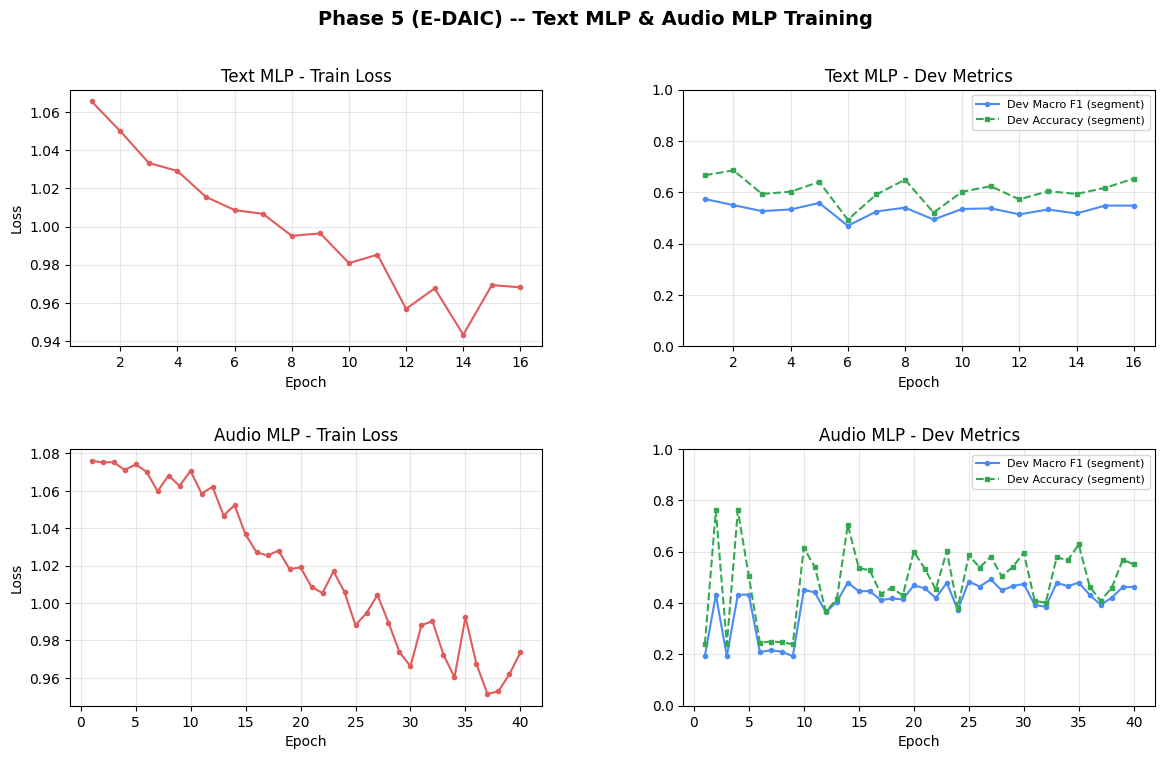

Plot saved to checkpoints/phase5_training_curves.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))
fig.suptitle("Phase 5 (E-DAIC) -- Text MLP & Audio MLP Training", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(text_history["epoch"], text_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax1.set_title("Text MLP - Train Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(text_history["epoch"], text_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1 (segment)")
ax2.plot(text_history["epoch"], text_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy (segment)")
ax2.set_title("Text MLP - Dev Metrics")
ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(audio_history["epoch"], audio_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax3.set_title("Audio MLP - Train Loss")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss"); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(audio_history["epoch"], audio_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1 (segment)")
ax4.plot(audio_history["epoch"], audio_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy (segment)")
ax4.set_title("Audio MLP - Dev Metrics")
ax4.set_xlabel("Epoch"); ax4.set_ylim(0, 1); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.savefig(os.path.join(CHECKPOINT_DIR, "phase5_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to checkpoints/phase5_training_curves.png")

In [20]:
print("SECTION 14: EXTRACT 128-DIM SEGMENT-LEVEL INTERMEDIATE FEATURES FOR PHASE 6")

FEATURES_OUT_DIR = "/kaggle/working/phase5_intermediate_features"
os.makedirs(FEATURES_OUT_DIR, exist_ok=True)


def extract_features(model, X, device):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X, dtype=torch.float32).to(device)
        _, features = model(x)
    return features.cpu().numpy()


for split_name, text_X, audio_X, y, pids, seg_ids in [
    ("train", train_text_X, train_audio_X, train_y, train_pids, train_seg_ids),
    ("dev", dev_text_X, dev_audio_X, dev_y, dev_pids, dev_seg_ids),
    ("test", test_text_X, test_audio_X, test_y, test_pids, test_seg_ids),
]:
    text_feats = extract_features(text_model, text_X, device)     # (n_segments, 128)
    audio_feats = extract_features(audio_model, audio_X, device)  # (n_segments, 128)

    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_text_features.npy"), text_feats)
    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_audio_features.npy"), audio_feats)
    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_labels.npy"), y)
    with open(os.path.join(FEATURES_OUT_DIR, f"{split_name}_participant_ids.json"), "w") as f:
        json.dump(pids, f)
    with open(os.path.join(FEATURES_OUT_DIR, f"{split_name}_segment_ids.json"), "w") as f:
        json.dump(seg_ids, f)

    print(f"{split_name}: text_features {text_feats.shape}, audio_features {audio_feats.shape}, "
          f"labels {y.shape}, {len(set(pids))} unique participants")

print(f"\nAll intermediate features saved to {FEATURES_OUT_DIR}")
print("These are SEGMENT-LEVEL (n_segments, 128) arrays, not participant-level.")
print("Phase 6's Fusion MLP should train on them the same way, then apply the same")
print("aggregate_to_participant_level() pattern from Section 12 for its own final test metric.")

SECTION 14: EXTRACT 128-DIM SEGMENT-LEVEL INTERMEDIATE FEATURES FOR PHASE 6
train: text_features (1504, 128), audio_features (1504, 128), labels (1504,), 161 unique participants
dev: text_features (468, 128), audio_features (468, 128), labels (468,), 56 unique participants
test: text_features (436, 128), audio_features (436, 128), labels (436,), 56 unique participants

All intermediate features saved to /kaggle/working/phase5_intermediate_features
These are SEGMENT-LEVEL (n_segments, 128) arrays, not participant-level.
Phase 6's Fusion MLP should train on them the same way, then apply the same
aggregate_to_participant_level() pattern from Section 12 for its own final test metric.


In [21]:
print("SECTION 15: PACKAGE AND DOWNLOAD")

print("=" * 60)
print("OUTPUT FILES")
print("=" * 60)

for d in [CHECKPOINT_DIR, TEXT_EMB_OUT_DIR, FEATURES_OUT_DIR]:
    print(f"\n{d}:")
    for fname in sorted(os.listdir(d)):
        fpath = os.path.join(d, fname)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f"  {fname}  ({size_mb:.2f} MB)")

import shutil
from IPython.display import FileLink, display

PACKAGE_DIR = "/kaggle/working/phase5_package"
os.makedirs(PACKAGE_DIR, exist_ok=True)
shutil.copytree(CHECKPOINT_DIR, os.path.join(PACKAGE_DIR, "checkpoints"), dirs_exist_ok=True)
shutil.copytree(FEATURES_OUT_DIR, os.path.join(PACKAGE_DIR, "intermediate_features"), dirs_exist_ok=True)
shutil.copytree(TEXT_EMB_OUT_DIR, os.path.join(PACKAGE_DIR, "text_embeddings_joint"), dirs_exist_ok=True)

zip_path = "/kaggle/working/phase5_outputs"
shutil.make_archive(zip_path, "zip", PACKAGE_DIR)
zip_full_path = zip_path + ".zip"

size_mb = os.path.getsize(zip_full_path) / (1024 * 1024)
print(f"\nZipped all Phase 5 outputs to: {zip_full_path} ({size_mb:.2f} MB)")
display(FileLink(zip_full_path))

print("\nAll done. Download from the Output tab on Kaggle.")
print(f"\nSplit sizes packaged: train {len(train_y)} segments / {len(set(train_pids))} participants, "
      f"dev {len(dev_y)} segments / {len(set(dev_pids))} participants, "
      f"test {len(test_y)} segments / {len(set(test_pids))} participants")

SECTION 15: PACKAGE AND DOWNLOAD
OUTPUT FILES

/kaggle/working/checkpoints:
  audio_mlp_checkpoint.pt  (0.88 MB)
  phase5_training_curves.png  (0.14 MB)
  phase5_unimodal_results.txt  (0.00 MB)
  text_mlp_checkpoint.pt  (0.88 MB)

/kaggle/working/edaic-embeddings/text:
  300_segment001.npy  (0.00 MB)
  300_segment002.npy  (0.00 MB)
  300_segment003.npy  (0.00 MB)
  300_segment004.npy  (0.00 MB)
  301_segment001.npy  (0.00 MB)
  301_segment002.npy  (0.00 MB)
  301_segment003.npy  (0.00 MB)
  301_segment004.npy  (0.00 MB)
  301_segment005.npy  (0.00 MB)
  301_segment006.npy  (0.00 MB)
  301_segment007.npy  (0.00 MB)
  301_segment008.npy  (0.00 MB)
  301_segment009.npy  (0.00 MB)
  301_segment010.npy  (0.00 MB)
  302_segment001.npy  (0.00 MB)
  302_segment002.npy  (0.00 MB)
  302_segment003.npy  (0.00 MB)
  302_segment004.npy  (0.00 MB)
  302_segment005.npy  (0.00 MB)
  302_segment006.npy  (0.00 MB)
  303_segment001.npy  (0.00 MB)
  303_segment002.npy  (0.00 MB)
  303_segment003.npy  (0.0

/kaggle/working/phase5_outputs.zip


All done. Download from the Output tab on Kaggle.

Split sizes packaged: train 1504 segments / 161 participants, dev 468 segments / 56 participants, test 436 segments / 56 participants
